## Libraries, import data, etc.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import CSV data
df = pd.read_csv('avg2_transcibed_sequences_TaylorWin.csv')

# Display the first few rows of the dataframe
df.head(10)

,Sequence,Signal Type,Time (s),Frequency (Hz),Correlation Value
0,0,D,9.58,7867,0.81
1,0,A,11.64,6822,1.01
2,0,B,14.93,6774,0.99
3,0,D,16.40,7891,0.88
4,0,C,18.66,6846,1.01
5,0,D,20.14,7771,0.88
6,0,A,22.38,6726,0.99
7,0,F,25.68,10054,0.70
8,0,E,26.83,7531,0.62
9,0,F,28.37,10006,0.80


## Correlation values

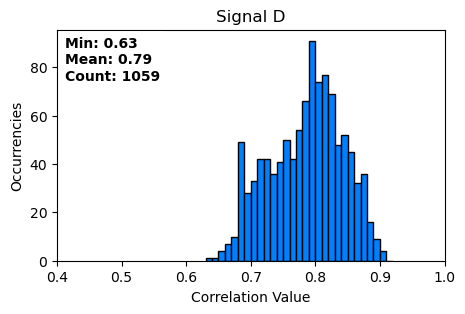

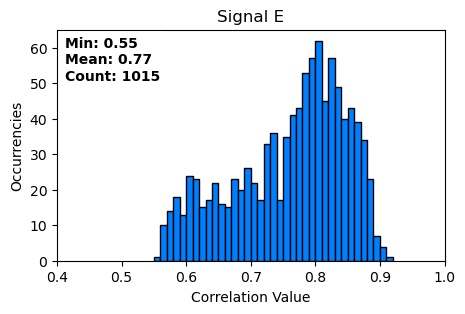

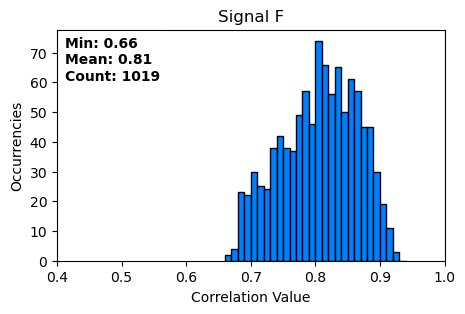

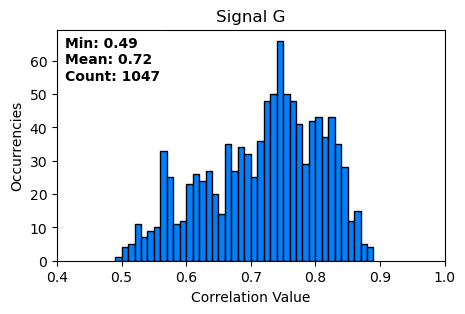

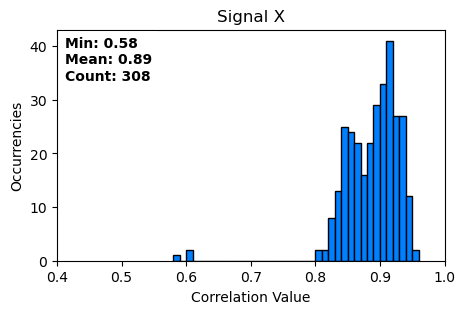

In [44]:
for signal_type in np.array(['D', 'E', 'F', 'G', 'X']): # 'A', 'B', 'C', 
    subset = df[df['Signal Type'] == signal_type] # Extract subset for each signal

    min_val = subset['Correlation Value'].min()
    max_val = subset['Correlation Value'].max()
    mean_val = (subset['Correlation Value']).mean()
    count = len(subset)
    
    plt.figure(figsize=(5, 3))
    bin_width = 0.01
    bins = np.arange(min_val, max_val + bin_width, bin_width)
    plt.hist(subset['Correlation Value'], bins=bins, alpha=1.0, label=signal_type, color="#0080ff", edgecolor='black')
    plt.title('Signal ' + str(signal_type))
    plt.xlabel('Correlation Value')
    plt.ylabel('Occurrencies')
    plt.xlim(0.4, 1.0)
    
    # Add the min and mean values in the upper-right corner
    plt.text(0.02, 0.97, f'Min: {min_val:.2f}\nMean: {mean_val:.2f}\nCount: {count}', 
             ha='left', va='top', transform=plt.gca().transAxes, 
             fontsize=10, color='black', weight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    
    plt.show()

## Signal occurrences

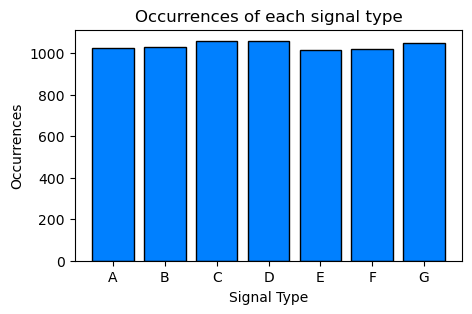

A: 1024
B: 1031
C: 1056
D: 1059
E: 1015
F: 1019
G: 1047


In [42]:
subset = df[df['Signal Type'] != "X"]
signal_counts = subset['Signal Type'].value_counts()
sorted_signal_types = sorted(signal_counts.index)
plt.figure(figsize=(5, 3))
plt.bar(sorted_signal_types, signal_counts[sorted_signal_types], alpha=1.0, color="#0080ff", edgecolor='black')
plt.title('Occurrences of each signal type')
plt.xlabel('Signal Type')
plt.ylabel('Occurrences')
plt.show()

for signal_type in np.array(['A', 'B', 'C', 'D', 'E', 'F', 'G']):
    print(f'{signal_type}: {np.count_nonzero(subset["Signal Type"] == signal_type)}')

## Frequency shifts

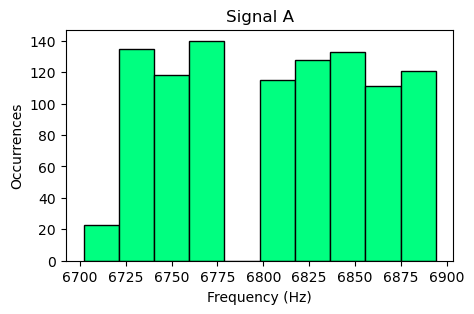

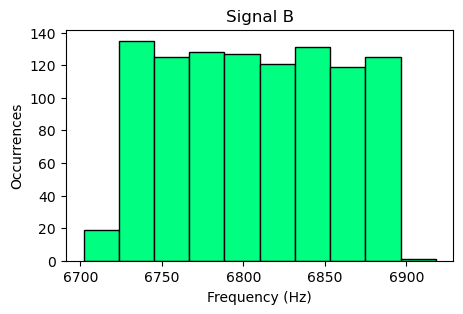

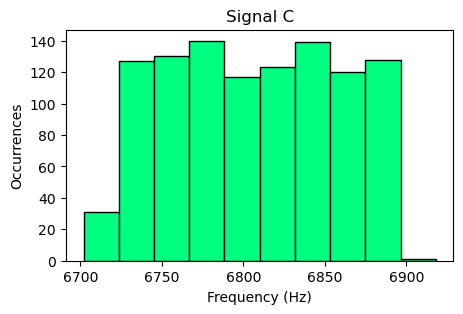

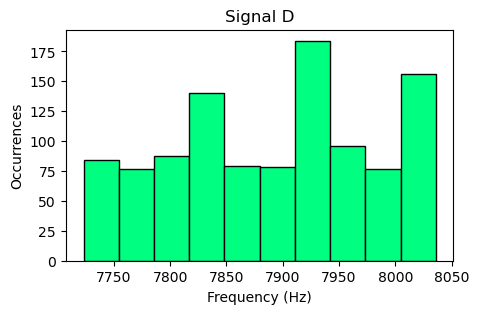

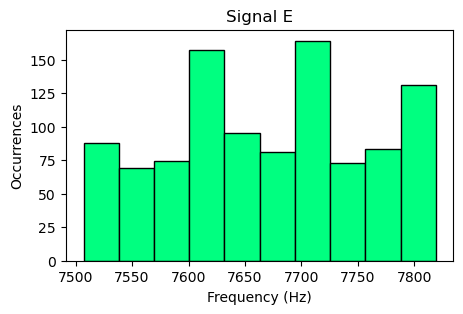

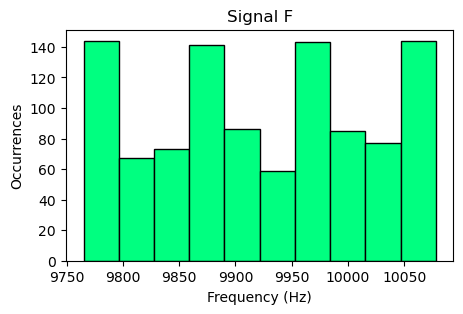

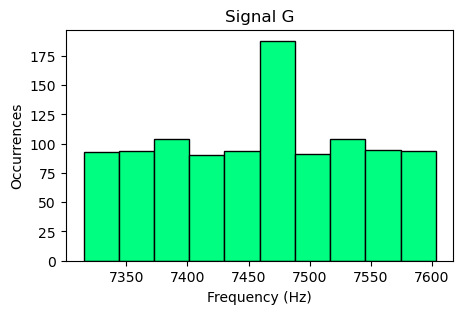

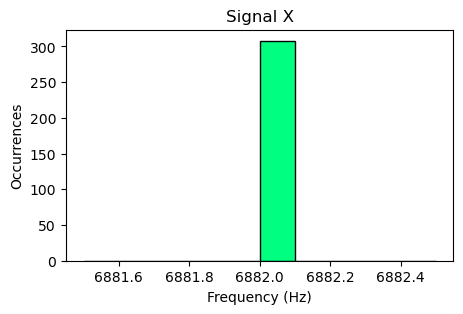

In [34]:
for signal_type in np.array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'X']):
    subset = df[df['Signal Type'] == signal_type] # Extract subset for each signal
    plt.figure(figsize=(5, 3))
    
    # Find min and max frequency values for the current signal type
    min_x = np.min(subset['Frequency (Hz)'])
    max_x = np.max(subset['Frequency (Hz)'])    
    bin_size = 24 # 24 Hz, the FFT resolution
    bin_edges = np.arange(min_x, max_x + bin_size, bin_size)  # +bin_size ensures the last bin covers the max frequency

    plt.hist(subset['Frequency (Hz)'], bins=10, alpha=1.0, label=signal_type, color="#00ff80", edgecolor='black') # Plot histogram for the 'Correlation Value' of each signal type
    plt.title('Signal ' + str(signal_type))
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Occurrences')

    plt.show()